In [1]:
import os
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)

# Vérifications rapides
assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

# Optionnel: filtrer les fichiers manquants
df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])




In [2]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val
# -------------------------
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

# -------------------------
# 4) Dataset + Transforms
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, "y"])

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, y

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle (Transfer Learning)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

Classes: ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:


best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")


Epoch 01 | train loss 0.5259 acc 0.7873 | val loss 0.4117 acc 0.8248
Epoch 02 | train loss 0.3416 acc 0.8617 | val loss 0.3457 acc 0.8620
Epoch 03 | train loss 0.2887 acc 0.8855 | val loss 0.3804 acc 0.8372
Epoch 04 | train loss 0.2326 acc 0.9103 | val loss 0.3098 acc 0.8785
Epoch 05 | train loss 0.1834 acc 0.9316 | val loss 0.3302 acc 0.8736
Epoch 06 | train loss 0.1711 acc 0.9380 | val loss 0.3238 acc 0.8752
Epoch 07 | train loss 0.1247 acc 0.9520 | val loss 0.3257 acc 0.8942
Epoch 08 | train loss 0.1209 acc 0.9558 | val loss 0.3444 acc 0.8893
Epoch 09 | train loss 0.1162 acc 0.9582 | val loss 0.3427 acc 0.8835
Epoch 10 | train loss 0.1037 acc 0.9649 | val loss 0.3926 acc 0.8876


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    y_proba = []  # softmax probabilities

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            preds = probs.argmax(dim=1).cpu().numpy()
            y_pred.append(preds)

            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_proba = np.concatenate(y_proba)  # (N, C)
    return y_true, y_pred, y_proba

def binary_metrics_from_cm(cm):
    # cm = [[TN, FP],
    #       [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-12)   # TPR / Recall
    spec = tn / (tn + fp + 1e-12)   # TNR
    ppv  = tp / (tp + fp + 1e-12)   # Precision
    npv  = tn / (tn + fn + 1e-12)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    return {"acc": acc, "sens": sens, "spec": spec, "ppv": ppv, "npv": npv}

def multiclass_sens_spec(cm):
    # One-vs-rest sensitivity & specificity per class
    C = cm.shape[0]
    total = cm.sum()
    out = []
    for k in range(C):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = total - tp - fn - fp
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        out.append((sens, spec))
    return out

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix (val)", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    # values in cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i, j]:.2f}" if normalize else str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


=== Confusion Matrix (val) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            250              0         9            41
True_glaucome             0            292         0             8
True_mda                  5              0       281            25
True_normaux              9             17        22           251


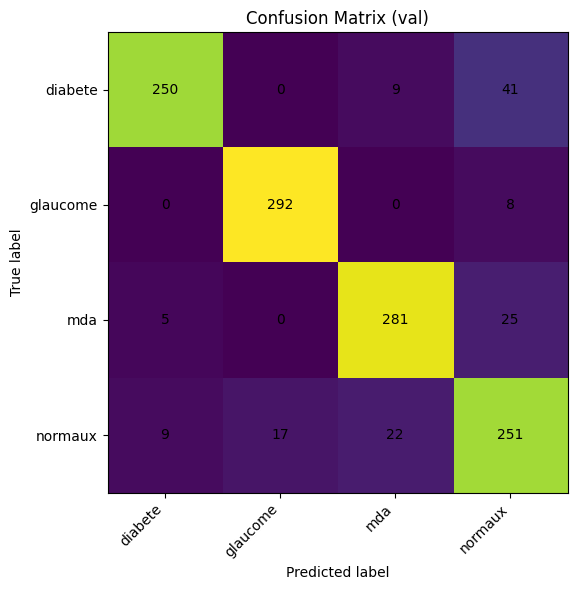


=== Classification report (val) ===
              precision    recall  f1-score   support

     diabete     0.9470    0.8333    0.8865       300
    glaucome     0.9450    0.9733    0.9589       300
         mda     0.9006    0.9035    0.9021       311
     normaux     0.7723    0.8395    0.8045       299

    accuracy                         0.8876      1210
   macro avg     0.8912    0.8874    0.8880      1210
weighted avg     0.8914    0.8876    0.8882      1210



In [5]:


# =========================
# UTILISATION (après entraînement)
# =========================

# device, model, val_loader, le, num_classes doivent déjà exister dans ton script

y_true, y_pred, y_proba = predict_on_loader(model, val_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (val) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (val)")

# ---- Rapport complet
print("\n=== Classification report (val) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))



In [6]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

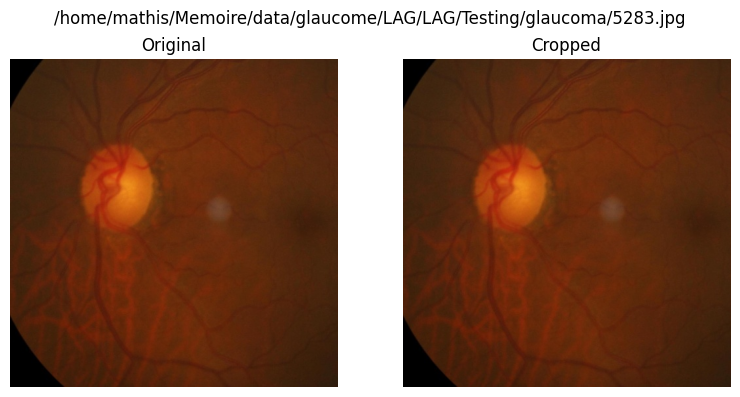

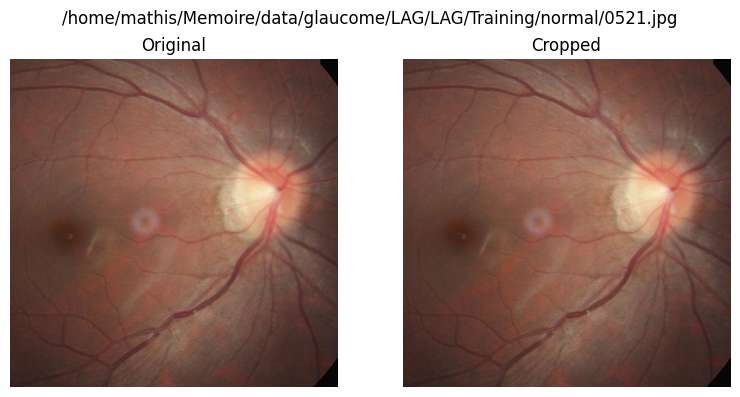

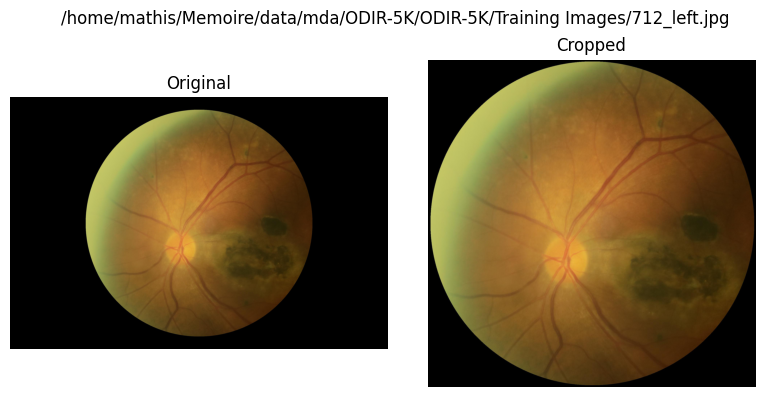

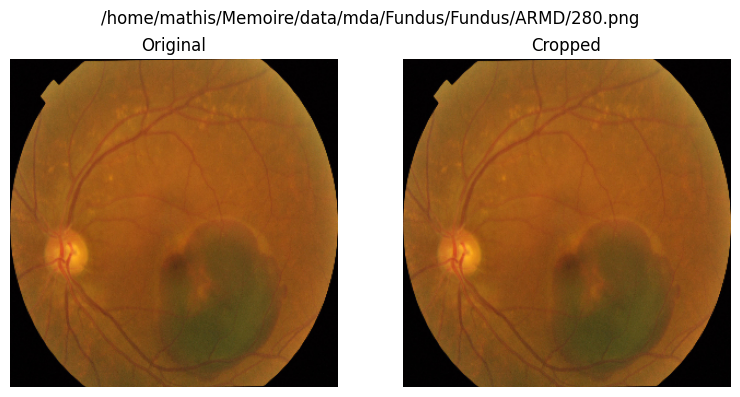

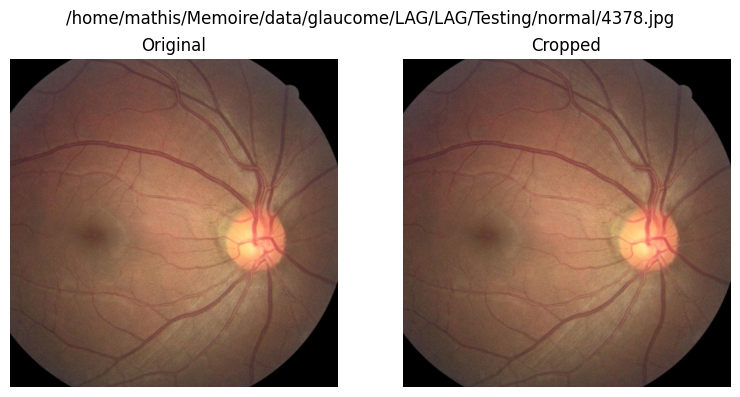

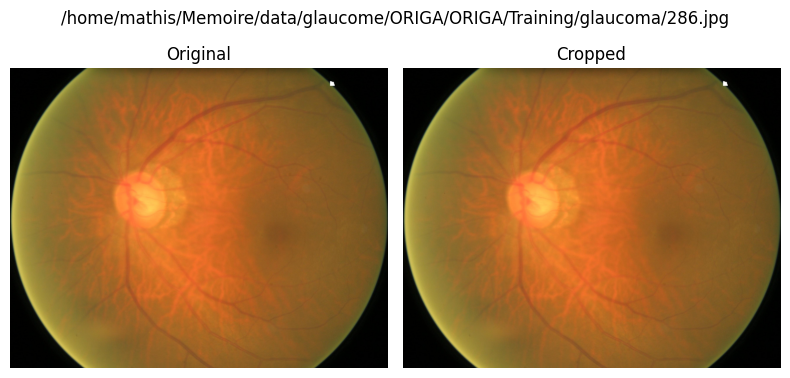

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

sample_paths = df["path"].sample(6, random_state=0).tolist()

for p in sample_paths:
    img = Image.open(p).convert("RGB")
    cropped = crop_black_border_pil(img, thr=10, pad=10)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped)
    axes[1].set_title("Cropped")
    axes[1].axis("off")

    fig.suptitle(p)
    plt.tight_layout()
    plt.show()


In [8]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val
# -------------------------
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

# -------------------------
# 4) Dataset + Transforms
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")

        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)

        if self.transform:
            img = self.transform(img)

        return img, y



train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle (Transfer Learning)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")


Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Epoch 01 | train loss 0.5189 acc 0.7928 | val loss 0.4138 acc 0.8248
Epoch 02 | train loss 0.3296 acc 0.8722 | val loss 0.3429 acc 0.8669
Epoch 03 | train loss 0.2693 acc 0.8950 | val loss 0.2945 acc 0.8785
Epoch 04 | train loss 0.2104 acc 0.9163 | val loss 0.3835 acc 0.8446
Epoch 05 | train loss 0.1706 acc 0.9343 | val loss 0.3278 acc 0.8694
Epoch 06 | train loss 0.1380 acc 0.9479 | val loss 0.3912 acc 0.8636
Epoch 07 | train loss 0.0927 acc 0.9663 | val loss 0.3242 acc 0.8942
Epoch 08 | train loss 0.0622 acc 0.9802 | val loss 0.3391 acc 0.8983
Epoch 09 | train loss 0.0528 acc 0.9841 | val loss 0.3396 acc 0.8950
Epoch 10 | train loss 0.0441 acc 0.9870 | val loss 0.3424 acc 0.8983



=== Confusion Matrix (val) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            272              0         3            25
True_glaucome             0            286         0            14
True_mda                  3              1       293            14
True_normaux             20             16        27           236


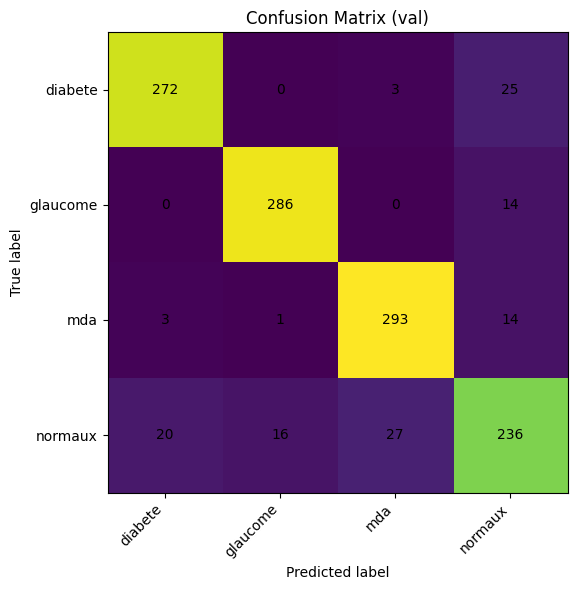


=== Classification report (val) ===
              precision    recall  f1-score   support

     diabete     0.9220    0.9067    0.9143       300
    glaucome     0.9439    0.9533    0.9486       300
         mda     0.9071    0.9421    0.9243       311
     normaux     0.8166    0.7893    0.8027       299

    accuracy                         0.8983      1210
   macro avg     0.8974    0.8979    0.8975      1210
weighted avg     0.8976    0.8983    0.8978      1210



In [9]:
y_true, y_pred, y_proba = predict_on_loader(model, val_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (val) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (val)")

# ---- Rapport complet
print("\n=== Classification report (val) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


2026-02-02 20:03:31.926548: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Nombre d'images mal classées : 123


I0000 00:00:1770059014.792285    9839 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


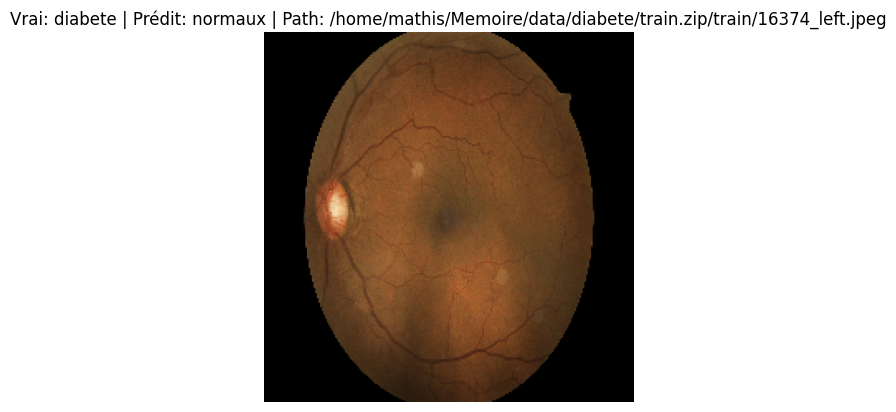

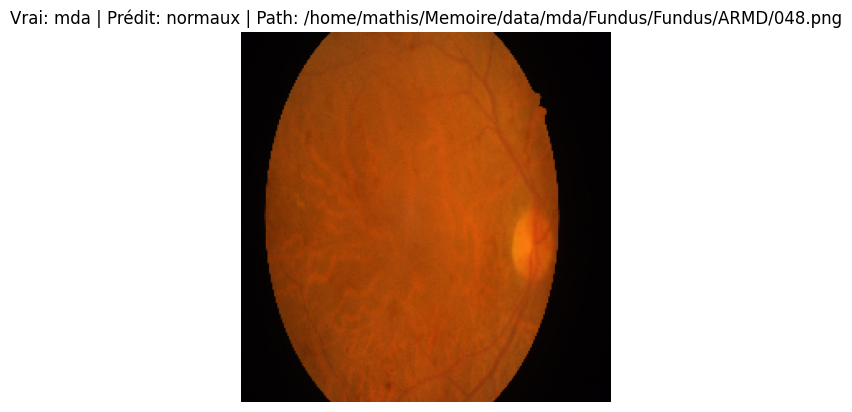

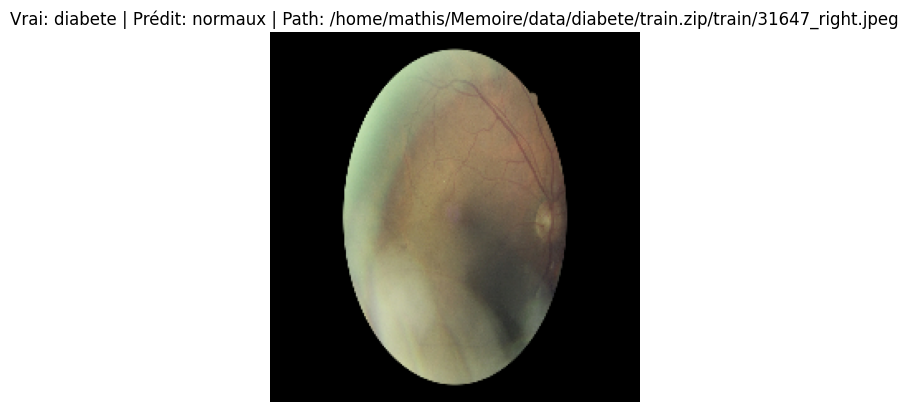

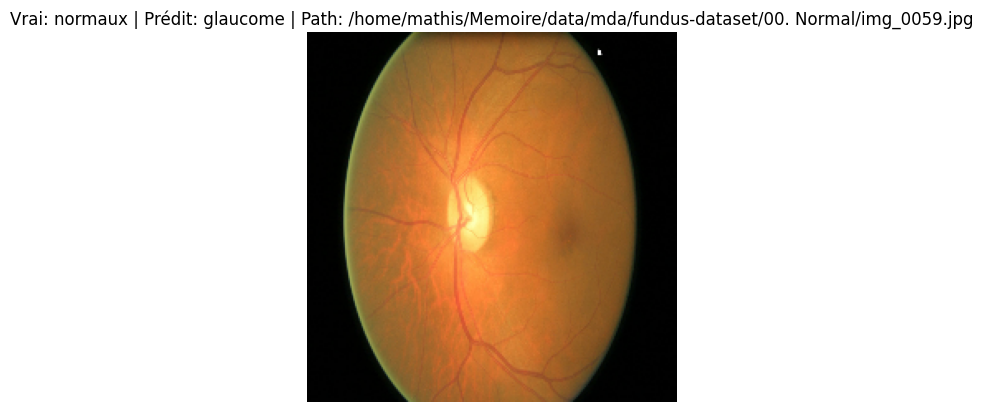

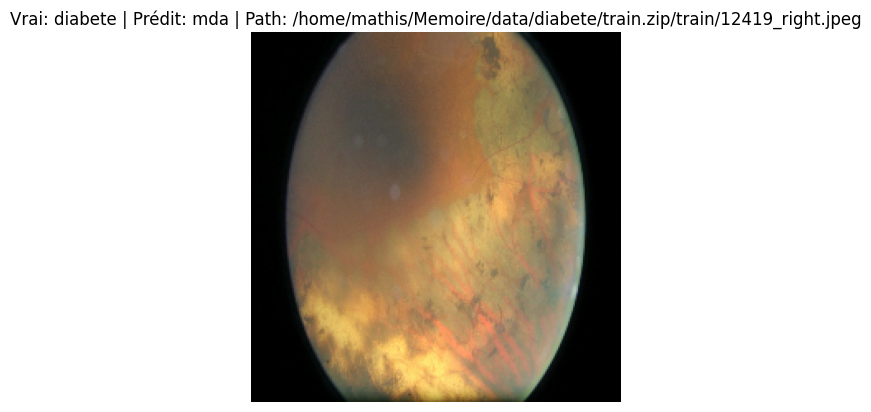

In [10]:
#montre des exemples d'images mal classées
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
df_test = val_df.reset_index(drop=True)
classes = le.classes_
IMG = 224
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")   
for idx in misclassified_indices[:5]:  # Affiche les 5 premières erreurs
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [IMG, IMG])

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Path: {img_path}")
    plt.axis("off")
    plt.show()

In [11]:

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} train acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} val acc {va_acc:.4f} | "
          f"lr {current_lr:.2e} "
          )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping déclenché à l'epoch {epoch}")
        break



Epoch 01 | train loss 0.0949 train acc 0.9644 | val loss 0.4850 val acc 0.8579 | lr 1.00e-04 
Epoch 02 | train loss 0.0910 train acc 0.9659 | val loss 0.3890 val acc 0.8868 | lr 1.00e-04 
Epoch 03 | train loss 0.0982 train acc 0.9626 | val loss 0.5152 val acc 0.8579 | lr 1.00e-04 
Epoch 04 | train loss 0.0701 train acc 0.9756 | val loss 0.4161 val acc 0.8917 | lr 1.00e-04 
Epoch 05 | train loss 0.0648 train acc 0.9785 | val loss 0.4510 val acc 0.8793 | lr 1.00e-04 
Epoch 06 | train loss 0.0557 train acc 0.9818 | val loss 0.3723 val acc 0.8950 | lr 1.00e-04 
Epoch 07 | train loss 0.0442 train acc 0.9855 | val loss 0.4011 val acc 0.8884 | lr 1.00e-04 
Epoch 08 | train loss 0.0496 train acc 0.9828 | val loss 0.4646 val acc 0.8802 | lr 1.00e-04 
Epoch 09 | train loss 0.0567 train acc 0.9804 | val loss 0.5952 val acc 0.8702 | lr 1.00e-04 
Epoch 10 | train loss 0.0391 train acc 0.9880 | val loss 0.5102 val acc 0.8884 | lr 1.00e-04 
Epoch 11 | train loss 0.0449 train acc 0.9837 | val loss 0.7

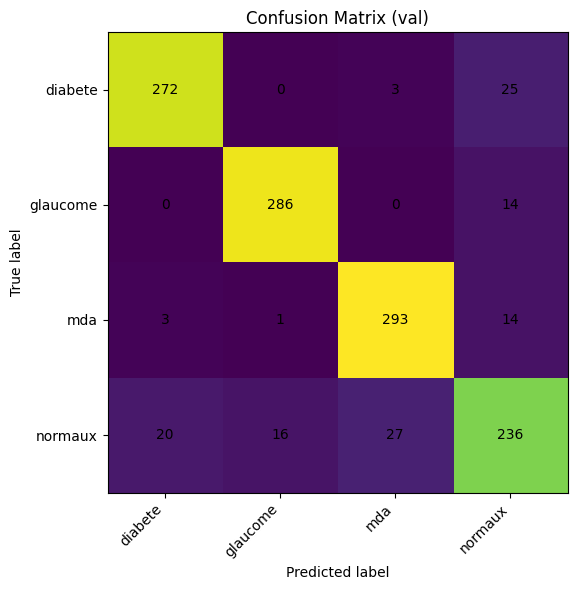

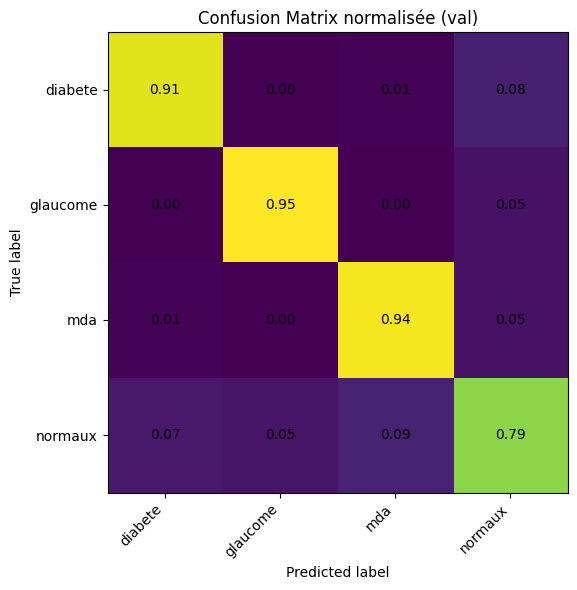


=== Classification report (val) ===
              precision    recall  f1-score   support

     diabete     0.9172    0.9233    0.9203       300
    glaucome     0.9472    0.9567    0.9519       300
         mda     0.9228    0.9228    0.9228       311
     normaux     0.8163    0.8027    0.8094       299

    accuracy                         0.9017      1210
   macro avg     0.9009    0.9014    0.9011      1210
weighted avg     0.9012    0.9017    0.9014      1210



In [12]:
y_true, y_pred, y_proba = predict_on_loader(model, val_loader, device)



# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (val)")
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix normalisée (val)", normalize=True)

# ---- Rapport complet
print("\n=== Classification report (val) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


Nombre d'images mal classées : 119


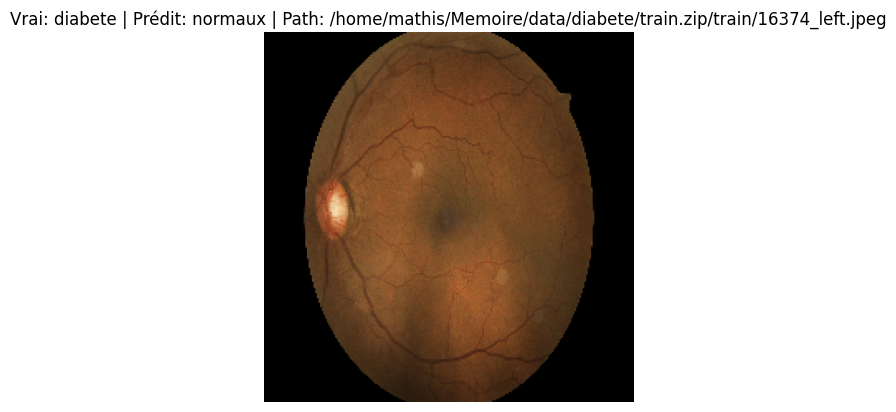

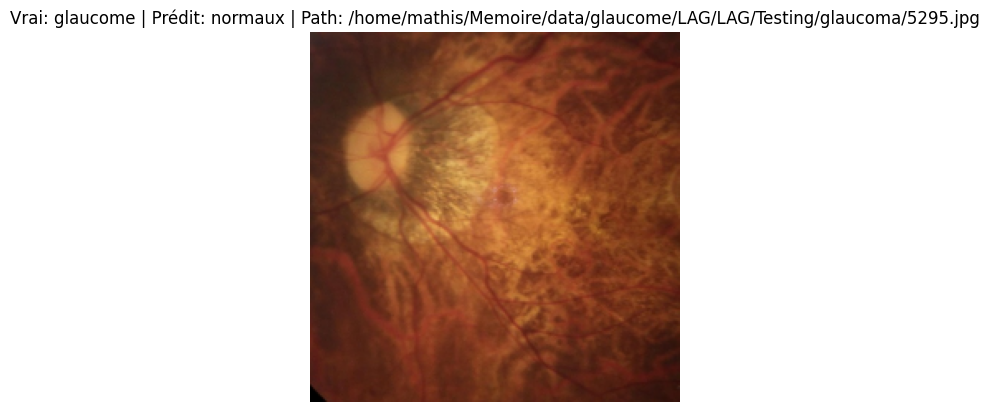

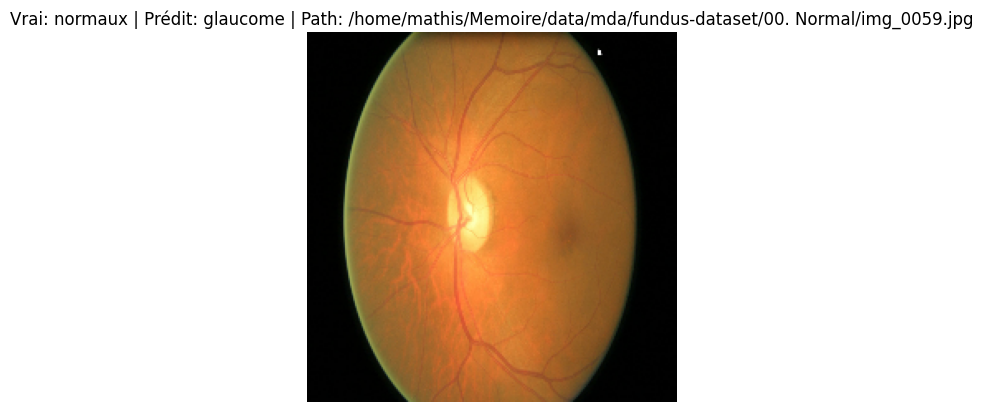

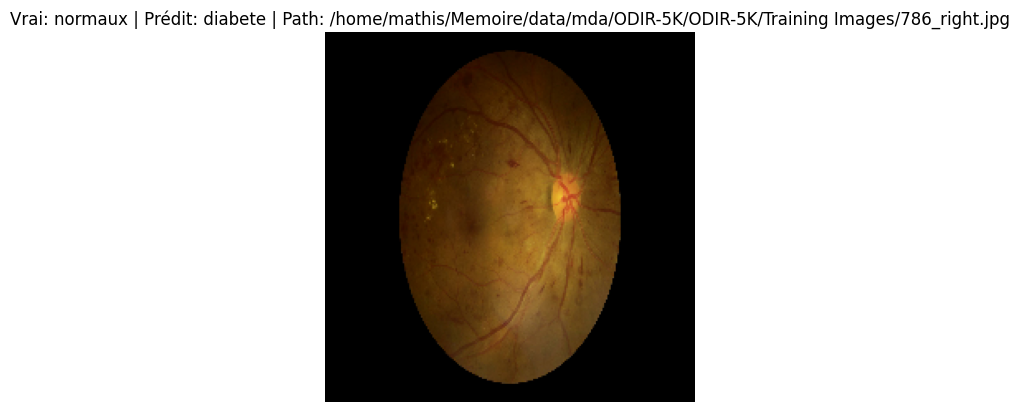

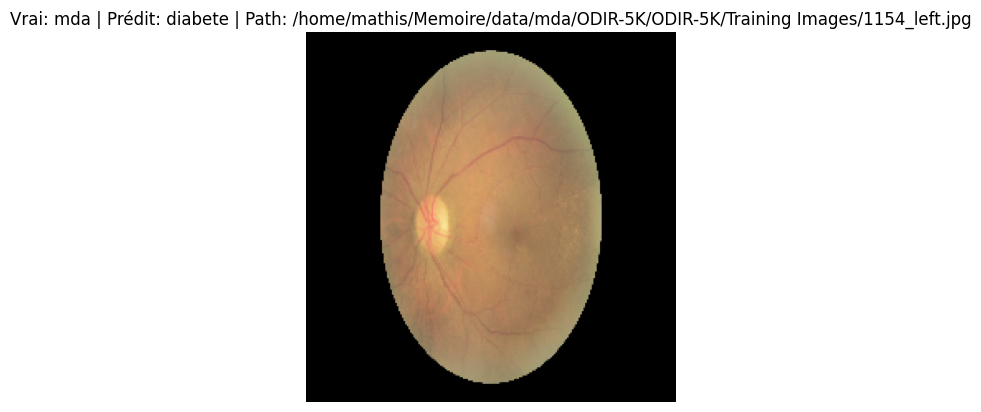

In [13]:
#montre des exemples d'images mal classées
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
df_test = val_df.reset_index(drop=True)
classes = le.classes_
IMG = 224
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")   
for idx in misclassified_indices[:5]:  # Affiche les 5 premières erreurs
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [IMG, IMG])

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Path: {img_path}")
    plt.axis("off")
    plt.show()